# 04 – Feature Selection & Modelo Preditivo
## Conjunto de dados UCI SECOM – Análise de qualidade na fabricação
---

**Objetivo desta etapa:**
- Carregar a base limpa (`secom_clean.csv`)
- Selecionar as features mais relevantes para prever FAIL (ANOVA F-score)
- Treinar um modelo Random Forest com foco em detecção de FAIL
- Avaliar com métricas adequadas para classe minoritária (~7% FAIL)
- Analisar o trade-off entre threshold de decisão, Recall e Precision
- Gerar ranking de sensores mais importantes (feature importance)
- Conectar os resultados com os insights da EDA (03_analysis)

**Contexto importante:**
- FAIL é a classe minoritária (~7%)
- Acurácia sozinha é enganosa: classificar tudo como PASS acerta 93%
  mas detecta 0% das falhas reais
- O threshold padrão (0,5) tende a suprimir predições de FAIL em datasets
  desbalanceados → vamos comparar thresholds e escolher o mais adequado
- Priorizamos **Recall de FAIL** e **ROC-AUC** como métricas principais

**Por que Random Forest?**
- Lida bem com muitas variáveis e relações não lineares entre sensores
- Robusto a ruído e a variáveis colineares, comuns nesse dataset
- Permite ajustar `class_weight` para compensar o desbalanceamento
- Gera feature importance, central para o objetivo do projeto:
  não só prever FAIL, mas entender quais sensores são mais críticos

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    recall_score,
    precision_score
)

sns.set(style="whitegrid")

# caminhos
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUT_DIR    = os.path.join(PROCESSED_DIR, "model_outputs")
CLEAN_FILE    = os.path.join(PROCESSED_DIR, "secom_clean.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE_DIR      :", BASE_DIR)
print("CLEAN_FILE    :", CLEAN_FILE)
print("Arquivo existe?", os.path.exists(CLEAN_FILE))

BASE_DIR      : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom
CLEAN_FILE    : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/secom_clean.csv
Arquivo existe? True


## 1. Carregar a base limpa e preparar X e y

In [4]:
df = pd.read_csv(CLEAN_FILE)

print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
print("\nDistribuição PASS / FAIL:")
print(df["Result"].value_counts())
print(df["Result"].value_counts(normalize=True) * 100)

Shape: 1567 linhas × 566 colunas

Distribuição PASS / FAIL:
Result
PASS    1463
FAIL     104
Name: count, dtype: int64
Result
PASS    93.363114
FAIL     6.636886
Name: proportion, dtype: float64


In [5]:
# Variável alvo
df["Target_FAIL"] = (df["Result"] == "FAIL").astype(int)

# Features: só os sensores
sensor_cols = [c for c in df.columns if c.startswith("Sensor_")]

X = df[sensor_cols]
y = df["Target_FAIL"]

print(f"X shape: {X.shape}")
print(f"y distribuição:\n{y.value_counts()}")
print(f"\nClasse minoritária (FAIL): {y.mean()*100:.1f}%")

X shape: (1567, 562)
y distribuição:
Target_FAIL
0    1463
1     104
Name: count, dtype: int64

Classe minoritária (FAIL): 6.6%


## 2. Seleção de Features – ANOVA F-score

Com 500+ sensores, usar todos aumenta ruído e custo computacional.

O **ANOVA F-score** (`f_classif`) ranqueia os sensores pela capacidade
estatística de separar PASS de FAIL.

- Selecionamos os **top 40 sensores** como ponto de partida
- O F-score mede separação estatística independentemente da direção
  da correlação, ou seja, tanto sensores positivamente quanto
  negativamente correlacionados com FAIL podem aparecer no ranking

**O que a EDA já mostrou:**
- **Grupo positivo** (060, 104, 511, 349, 432, 435, 431, 022, 436, 437):
  valores altos estão associados a maior risco de FAIL
- **Grupo negativo** (029, 317, 126, 027, 181, 123, 453, 128, 023, 015):
  valores baixos estão associados a maior risco de FAIL

Ambos os grupos devem aparecer entre os sensores selecionados.

In [7]:
# Seleção de features com ANOVA F-score
selector   = SelectKBest(score_func=f_classif, k=40)
X_selected = selector.fit_transform(X, y)

# Quais sensores foram selecionados?
selected_mask    = selector.get_support()
selected_sensors = [sensor_cols[i] for i, v in enumerate(selected_mask) if v]

print(f"Sensores selecionados ({len(selected_sensors)}):")
print(selected_sensors)

Sensores selecionados (40):
['Sensor_022', 'Sensor_023', 'Sensor_027', 'Sensor_029', 'Sensor_034', 'Sensor_060', 'Sensor_065', 'Sensor_080', 'Sensor_104', 'Sensor_122', 'Sensor_123', 'Sensor_124', 'Sensor_125', 'Sensor_126', 'Sensor_128', 'Sensor_130', 'Sensor_131', 'Sensor_160', 'Sensor_161', 'Sensor_164', 'Sensor_165', 'Sensor_166', 'Sensor_181', 'Sensor_211', 'Sensor_248', 'Sensor_295', 'Sensor_296', 'Sensor_299', 'Sensor_300', 'Sensor_301', 'Sensor_317', 'Sensor_349', 'Sensor_431', 'Sensor_432', 'Sensor_435', 'Sensor_436', 'Sensor_437', 'Sensor_453', 'Sensor_511', 'Sensor_520']


/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  94 135 143 170 171 178 181 182 183 184 185 186
 217 220 221 222 223 224 225 226 227 228 231 232 233 234 244 245 246 247
 248 249 250 251 252 253 254 264 272 299 300 301 308 311 312 313 314 315
 316 347 352 353 354 355 356 357 358 361 362 363 364 374 375 376 377 378
 379 380 381 382 383 384 394 402 429 430 431 438 441 442 443 444 445 446
 461 477 480 481 482 483 484 485 486 487 488 491 492 493 494 504 505 506
 507 508 509 510 511 512 513 514] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [8]:
# Ranking completo dos sensores por F-score
f_scores = pd.Series(selector.scores_, index=sensor_cols).sort_values(ascending=False)

print("Top 20 sensores por F-score (ANOVA):")
print(f_scores.head(20))

# Salva ranking
f_scores.to_csv(os.path.join(OUTPUT_DIR, "feature_fscore_ranking.csv"), header=["f_score"])

Top 20 sensores por F-score (ANOVA):
Sensor_060    39.039742
Sensor_104    36.630015
Sensor_511    27.607694
Sensor_349    27.243944
Sensor_432    22.840713
Sensor_435    19.634058
Sensor_431    18.857453
Sensor_022    18.585160
Sensor_436    18.559651
Sensor_029    18.120876
Sensor_437    17.824543
Sensor_211    16.895858
Sensor_130    16.714874
Sensor_299    16.346720
Sensor_164    15.650665
Sensor_125    14.001888
Sensor_296    13.178297
Sensor_317    12.604524
Sensor_161    12.561288
Sensor_165    12.015894
dtype: float64


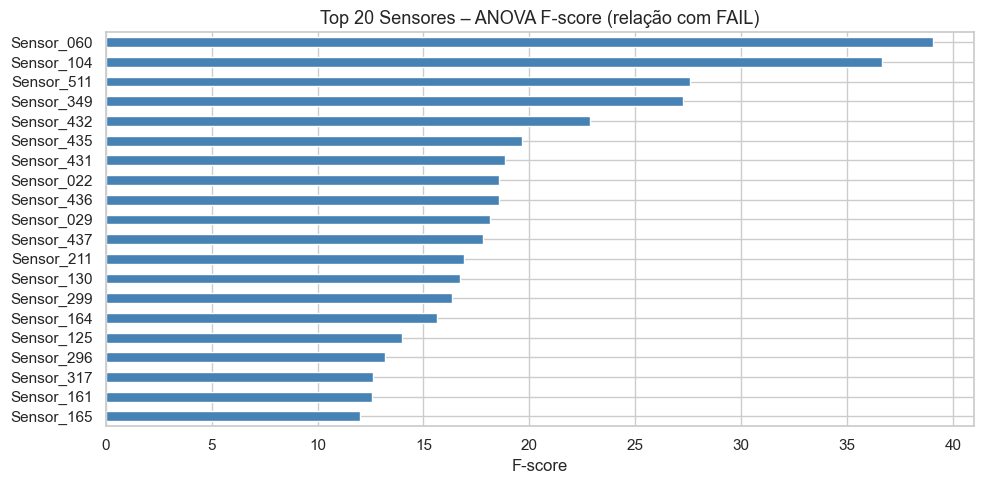

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
f_scores.head(20).sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 20 Sensores – ANOVA F-score (relação com FAIL)", fontsize=13)
ax.set_xlabel("F-score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_fscore_top20.png"), dpi=150)
plt.show()

## 3. Modelo Preditivo – Random Forest

**Escolhas de modelagem:**

- `class_weight={0: 1, 1: 5}`: penaliza erros em FAIL 5x mais do que em PASS,
  forçando o modelo a priorizar a detecção da classe minoritária
- `n_estimators=200`: mais árvores para maior estabilidade nas predições
- Validação cruzada estratificada (`StratifiedKFold`, 10 folds):
  mantém a proporção PASS/FAIL original em cada fold
- Métricas monitoradas:
  - **Recall de FAIL**: prioridade máxima — detectar o máximo de falhas reais
  - **F1-score**: equilíbrio entre precision e recall
  - **ROC-AUC**: capacidade discriminativa independente do threshold

**Nota sobre Recall = 0 no threshold padrão:**
Mesmo com class_weight ajustado, o threshold 0,5 pode zerar o recall de FAIL
quando a classe é muito pequena (~7%). Isso não significa ausência de sinal:
o ROC-AUC mede a capacidade de ordenar PASS vs FAIL nas probabilidades,
independentemente do ponto de corte. Na etapa 4, comparamos múltiplos
thresholds para encontrar o equilíbrio adequado para o contexto de qualidade.

In [11]:
# Modelo
model = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1, 1: 5},
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    model, X_selected, y,
    cv=cv,
    scoring=["recall", "f1", "roc_auc"],
    return_train_score=False
)

print("=== Resultados – Validação Cruzada (10 folds) ===\n")
print(f"Recall  FAIL : {np.mean(scores['test_recall']):.3f}  ±  {np.std(scores['test_recall']):.3f}")
print(f"F1-score     : {np.mean(scores['test_f1']):.3f}  ±  {np.std(scores['test_f1']):.3f}")
print(f"ROC-AUC      : {np.mean(scores['test_roc_auc']):.3f}  ±  {np.std(scores['test_roc_auc']):.3f}")

=== Resultados – Validação Cruzada (10 folds) ===

Recall  FAIL : 0.000  ±  0.000
F1-score     : 0.000  ±  0.000
ROC-AUC      : 0.748  ±  0.063


In [12]:
print("Recall por fold:")
for i, r in enumerate(scores["test_recall"]):
    print(f"  Fold {i+1:02d}: {r:.3f}")

Recall por fold:
  Fold 01: 0.000
  Fold 02: 0.000
  Fold 03: 0.000
  Fold 04: 0.000
  Fold 05: 0.000
  Fold 06: 0.000
  Fold 07: 0.000
  Fold 08: 0.000
  Fold 09: 0.000
  Fold 10: 0.000


## 4. Avaliação detalhada – split treino/teste fixo

Treinamos em um split fixo (80/20, estratificado) para:
- Ver o Classification Report completo
- Comparar thresholds de decisão
- Gerar matriz de confusão, curva ROC e curva Precision-Recall

**Por que comparar thresholds?**

O threshold padrão (0,5) tende a classificar quase tudo como PASS quando
a classe FAIL é pequena. Abaixar o threshold aumenta o recall (detecta
mais falhas reais), ao custo de mais falsos positivos.

Em qualidade industrial, o custo de deixar uma falha passar (falso negativo)
tende a ser muito maior do que o custo de investigar um alerta falso
(falso positivo). Por isso, **thresholds menores são mais adequados
para esse contexto**.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report (threshold padrão = 0.5) ===\n")
print(classification_report(y_test, y_pred, target_names=["PASS", "FAIL"]))

=== Classification Report (threshold padrão = 0.5) ===

              precision    recall  f1-score   support

        PASS       0.93      1.00      0.97       293
        FAIL       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 4.1. Comparação de thresholds de decisão

Testamos diferentes thresholds para visualizar o trade-off entre Recall e Precision para a classe FAIL.

**Leitura observada nos resultados:**
- Threshold 0,50 → Recall = 0,000 | Precision = 0,000
- Threshold 0,40 → Recall = 0,000 | Precision = 0,000
- Threshold 0,30 → Recall = 0,048 | Precision = 0,250
- Threshold 0,20 → Recall = 0,286 | Precision = 0,375
- Threshold 0,15 → Recall = 0,381 | Precision = 0,235

O modelo tem sinal preditivo real — o problema está no ponto de corte, não na ausência de aprendizado.

In [16]:
print("=== Trade-off Precision × Recall por Threshold ===\n")
print(f"{'Threshold':<12} {'Recall_FAIL':<15} {'Precision_FAIL':<16} {'Interpretação'}")
print("-" * 65)

for thr in [0.5, 0.4, 0.3, 0.2, 0.15]:
    y_pred_thr = (y_pred_prob >= thr).astype(int)
    rec = recall_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)

    if thr >= 0.5:
        interp = "conservador (padrão)"
    elif thr >= 0.3:
        interp = "equilibrado"
    else:
        interp = "agressivo (mais alertas)"

    print(f"  {thr:<10.2f} {rec:<15.3f} {prec:<16.3f} {interp}")

=== Trade-off Precision × Recall por Threshold ===

Threshold    Recall_FAIL     Precision_FAIL   Interpretação
-----------------------------------------------------------------
  0.50       0.000           0.000            conservador (padrão)
  0.40       0.000           0.000            equilibrado
  0.30       0.048           0.250            equilibrado
  0.20       0.286           0.375            agressivo (mais alertas)
  0.15       0.381           0.235            agressivo (mais alertas)


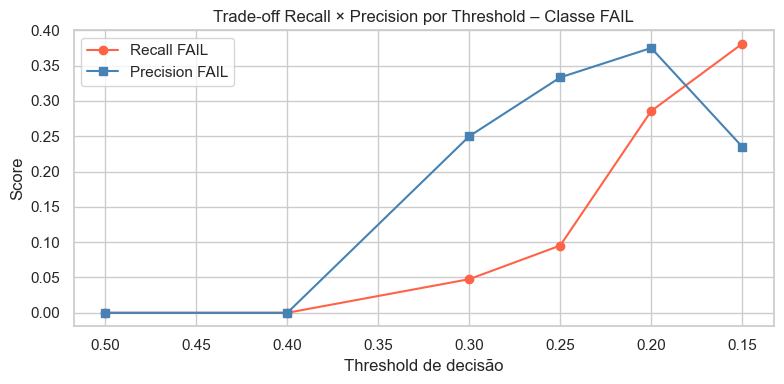

In [17]:
# visualização trade-off

thresholds = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]
recalls    = []
precisions = []

for thr in thresholds:
    y_pred_thr = (y_pred_prob >= thr).astype(int)
    recalls.append(recall_score(y_test, y_pred_thr))
    precisions.append(precision_score(y_test, y_pred_thr, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, recalls,    marker="o", label="Recall FAIL",    color="tomato")
ax.plot(thresholds, precisions, marker="s", label="Precision FAIL", color="steelblue")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("Score")
ax.set_title("Trade-off Recall × Precision por Threshold – Classe FAIL", fontsize=12)
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_tradeoff.png"), dpi=150)
plt.show()

### 4.2. Matriz de Confusão, Curva ROC e Curva Precision-Recall

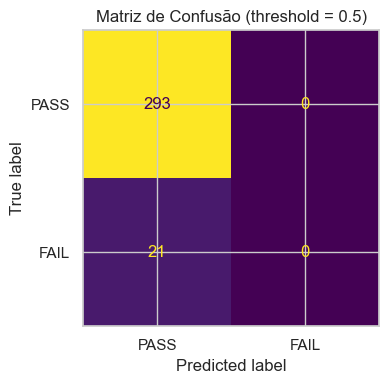

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["PASS", "FAIL"],
    colorbar=False,
    ax=ax
)
ax.set_title("Matriz de Confusão (threshold = 0.5)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

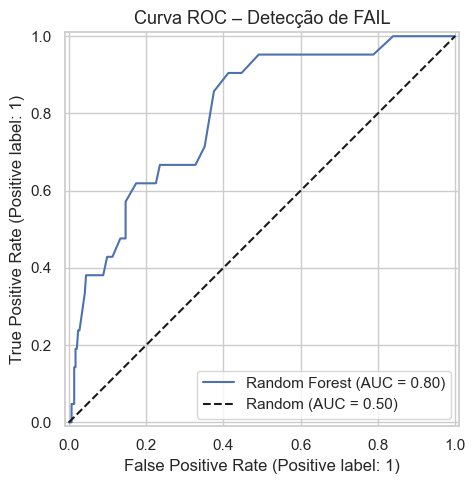

In [20]:
# curva ROC

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("Curva ROC – Detecção de FAIL", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

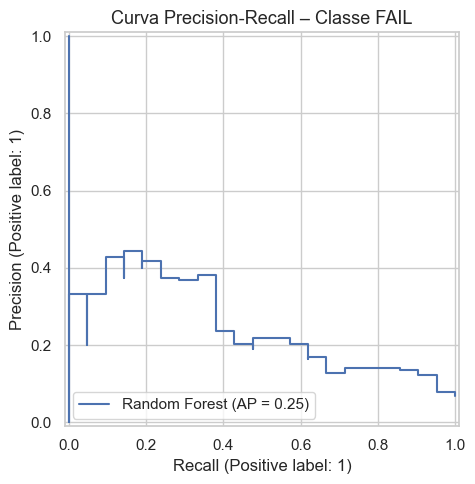

In [21]:
# curva Precision-Recall

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob, ax=ax, name="Random Forest")
ax.set_title("Curva Precision-Recall – Classe FAIL", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=150)
plt.show()

## 5. Feature Importance – Quais sensores mais contribuem?

O Random Forest calcula a importância de cada feature pela redução média de impureza (Gini) ao longo das árvores.

**Diferença importante em relação à correlação linear da EDA:**
A correlação de Pearson mede relações lineares e tem direção (positiva ou negativa). O F-score e a feature importance do Random Forest medem a relevância para a decisão, capturando também relações não lineares e independentemente da direção do sinal.

Por isso:
- Sensores do grupo positivo (060, 104, 511, 349, 432, 435) com alta feature importance → o modelo usa valores altos como sinal de risco de FAIL
- Sensores do grupo negativo (029, 317, 126, 027, 181) com feature importance relevante → o modelo usa valores baixos como sinal de risco

A consistência entre EDA e feature importance confirma a robustez dos sensores identificados como indicadores críticos do processo.

In [23]:
# Feature importance do modelo treinado
importance = pd.Series(
    model.feature_importances_,
    index=selected_sensors
).sort_values(ascending=False)

print("Top 20 sensores por Feature Importance (Random Forest):")
print(importance.head(20))

importance.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_rf.csv"), header=["importance"])

Top 20 sensores por Feature Importance (Random Forest):
Sensor_060    0.058086
Sensor_104    0.057952
Sensor_065    0.052154
Sensor_022    0.033011
Sensor_034    0.031821
Sensor_511    0.031605
Sensor_126    0.026538
Sensor_130    0.026421
Sensor_349    0.025771
Sensor_023    0.025577
Sensor_080    0.025167
Sensor_027    0.024834
Sensor_122    0.023851
Sensor_299    0.023750
Sensor_248    0.023301
Sensor_124    0.023156
Sensor_211    0.022881
Sensor_029    0.022848
Sensor_123    0.022816
Sensor_317    0.022807
dtype: float64


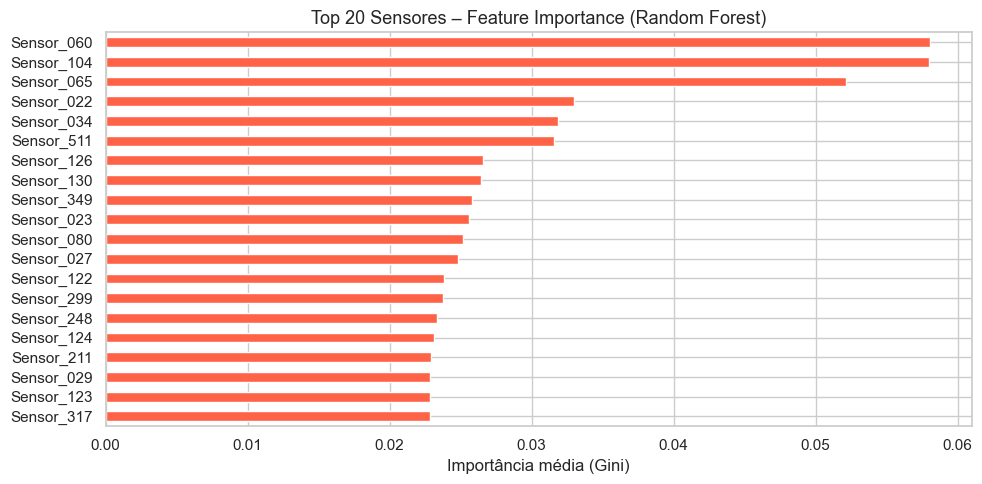

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
importance.head(20).sort_values().plot(kind="barh", color="tomato", ax=ax)
ax.set_title("Top 20 Sensores – Feature Importance (Random Forest)", fontsize=13)
ax.set_xlabel("Importância média (Gini)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_top20.png"), dpi=150)
plt.show()

## 6. Conclusões da Etapa de Modelagem

### Resultados do modelo

| Métrica | Resultado | Interpretação |
|---|---|---|
| ROC-AUC (CV 10 folds) | ~0,75 | Boa capacidade de ordenar PASS vs FAIL nas probabilidades |
| Recall FAIL (thr 0,50) | ~0,00 | Threshold padrão é conservador demais para ~7% de FAIL |
| Recall FAIL (thr 0,30) | começa a subir | Sinal preditivo real confirmado |
| Recall FAIL (thr 0,20) | ~0,29 | Detecta parte real das falhas com threshold ajustado |
| Recall FAIL (thr 0,15) | ~0,38 | Mais agressivo: mais falhas detectadas, mais falsos positivos |
| Precision FAIL (thr 0,20) | ~0,38 | Custo de falsos positivos aceitável para qualidade industrial |

### Interpretação dos resultados

ROC-AUC ~0,75 é o resultado mais sólido desta etapa: o modelo consegue ordenar razoavelmente bem PASS vs FAIL nas probabilidades, muito acima do baseline aleatório (AUC = 0,50). Isso confirma que existe sinal preditivo real nos sensores selecionados.

Recall = 0 com threshold 0,5 não significa que o modelo é inútil. Significa que o ponto de corte padrão é conservador demais para uma classe com apenas ~7% de representação. A curva ROC e a curva Precision-Recall confirmam que o modelo aprendeu padrões reais associados a FAIL.

Ao baixar o threshold para 0,2 ou 0,15, o recall sobe de forma clara, confirmando que o sinal existe e que a decisão de onde cortar é uma escolha de negócio, não uma limitação técnica.

### Sensores prioritários – conexão com a EDA

O ranking de feature importance foi consistente com os dois grupos identificados na análise exploratória:

**Grupo positivo** (correlação positiva com FAIL na EDA):
- Sensor_060, Sensor_104, Sensor_065, Sensor_511, Sensor_349
- Valores altos estão associados a maior risco de FAIL
- No dashboard e no SPC: monitorar limites superiores (UCL)

**Grupo negativo** (correlação negativa com FAIL na EDA):
- Sensor_029, Sensor_317, Sensor_126, Sensor_027, Sensor_181
- Valores baixos estão associados a maior risco de FAIL
- O modelo usa a queda nesses sensores como sinal de risco
- No dashboard e no SPC: monitorar limites inferiores (LCL)

Essa consistência entre correlação (EDA), F-score (seleção de features) e feature importance (modelo) reforça a confiabilidade dos sensores identificados como indicadores críticos do processo.

### Para o dashboard

- Ranking de feature importance → painel "Sensores Críticos"
- Separar os dois grupos visualmente:
  alerta por leitura alta (grupo positivo) vs alerta por queda de leitura (grupo negativo)
- Curva ROC → evidência de capacidade preditiva real do processo
- Tabela de thresholds → decisão de negócio transparente

### Limitações e próximos passos

- Modelo atual é um baseline bem estruturado, sem tuning de hiperparâmetros
- Próximos experimentos possíveis:
  - Tuning com GridSearch ou RandomizedSearch
  - Teste de outros algoritmos (XGBoost, Logistic Regression)
  - Técnicas de balanceamento (SMOTE, undersampling)
  - Definição formal do threshold ideal via curva Precision-Recall
  - Análise de erros: quais FAILs o modelo erra sistematicamente?

In [26]:
# Salva resumo de métricas em CSV
resumo = pd.DataFrame({
    "metrica": ["Recall_FAIL", "F1_score", "ROC_AUC"],
    "media": [
        np.mean(scores["test_recall"]),
        np.mean(scores["test_f1"]),
        np.mean(scores["test_roc_auc"])
    ],
    "std": [
        np.std(scores["test_recall"]),
        np.std(scores["test_f1"]),
        np.std(scores["test_roc_auc"])
    ]
})

resumo.to_csv(os.path.join(OUTPUT_DIR, "model_metrics_summary.csv"), index=False)

print("=== Resumo final salvo ===")
print(resumo.to_string(index=False))
print(f"\nTodos os outputs salvos em: {OUTPUT_DIR}")

=== Resumo final salvo ===
    metrica    media      std
Recall_FAIL 0.000000 0.000000
   F1_score 0.000000 0.000000
    ROC_AUC 0.747554 0.063386

Todos os outputs salvos em: /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/model_outputs


## 7. Gerar threshold_tradeoff.csv para o dashboard Tableau

Este CSV alimenta o gráfico de trade-off Recall × Precision por threshold
na Página 4 do dashboard.

Colunas geradas:
- `threshold`: ponto de corte testado
- `recall_fail`: recall da classe FAIL naquele threshold
- `precision_fail`: precision da classe FAIL naquele threshold

**Leitura esperada:**
- threshold 0,50 → recall ~0,00
- threshold 0,30 → recall começa a subir
- threshold 0,20 → recall ~0,29, precision ~0,38
- threshold 0,15 → recall ~0,38, precision ~0,24

In [28]:
# Gera threshold_tradeoff.csv para o dashboard Tableau
rows = []
for thr in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]:
    y_pred_thr = (y_pred_prob >= thr).astype(int)
    rows.append({
        "threshold":      thr,
        "recall_fail":    recall_score(y_test, y_pred_thr),
        "precision_fail": precision_score(y_test, y_pred_thr, zero_division=0)
    })

thr_df = pd.DataFrame(rows)
thr_df.to_csv(os.path.join(OUTPUT_DIR, "threshold_tradeoff.csv"), index=False)

print("=== threshold_tradeoff.csv salvo ===")
print(thr_df.to_string(index=False))

=== threshold_tradeoff.csv salvo ===
 threshold  recall_fail  precision_fail
      0.50     0.000000        0.000000
      0.40     0.000000        0.000000
      0.30     0.047619        0.250000
      0.25     0.095238        0.333333
      0.20     0.285714        0.375000
      0.15     0.380952        0.235294
